# Goal of the analysis

Ski pass prices vary a lot between resorts that at first view offer comparable experiences. 
This project investigates what factors determine the price of a ski lift pass worldwide.

To answer this, after having identified the possible suspects different categories of factors that
might explain pricing and we analyze each of them with the appropriate
statistical tests. 

## The four categories

1.  **The Mountain Itself** Do bigger, higher resorts charge more?
2.  **Geography and Wealth** Does location and country wealth drive pricing? 
3.  **Services and Positioning**  Do extras like snowparks or summer skiing justify a premium?
4.  **The Actual Snow** Does mean snow cover correlate with price?

## Libraries 

In [ ]:
install.packages("rio")
install.packages("dplyr")
install.packages("rcompanion")
install.packages("sjmisc")
library(rio)
library(dplyr)

library(rcompanion)

Installazione pacchetto in 'C:/Users/AlessandroMacchi/AppData/Local/R/win-library/4.6'
(perché 'lib' non è specificato)



package 'rio' successfully unpacked and MD5 sums checked

I pacchetti binari scaricati sono in
	C:\Users\AlessandroMacchi\AppData\Local\Temp\RtmpU5TJ9f\downloaded_packages


Installazione pacchetto in 'C:/Users/AlessandroMacchi/AppData/Local/R/win-library/4.6'
(perché 'lib' non è specificato)



package 'dplyr' successfully unpacked and MD5 sums checked


Warning message:
"non è possibile rimuovere una precedente installazione del pacchetto 'dplyr'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problema durante la copia di C:\Users\AlessandroMacchi\AppData\Local\R\win-library\4.6\00LOCK\dplyr\libs\x64\dplyr.dll in C:\Users\AlessandroMacchi\AppData\Local\R\win-library\4.6\dplyr\libs\x64\dplyr.dll: Permission denied"
Warning message:
"ripristinato 'dplyr'"


...

Installazione pacchetto in 'C:/Users/AlessandroMacchi/AppData/Local/R/win-library/4.6'
(perché 'lib' non è specificato)



package 'rcompanion' successfully unpacked and MD5 sums checked

I pacchetti binari scaricati sono in
	C:\Users\AlessandroMacchi\AppData\Local\Temp\RtmpU5TJ9f\downloaded_packages


Installazione pacchetto in 'C:/Users/AlessandroMacchi/AppData/Local/R/win-library/4.6'
(perché 'lib' non è specificato)



package 'sjmisc' successfully unpacked and MD5 sums checked

I pacchetti binari scaricati sono in
	C:\Users\AlessandroMacchi\AppData\Local\Temp\RtmpU5TJ9f\downloaded_packages



Caricamento pacchetto: 'dplyr'


I seguenti oggetti sono mascherati da 'package:stats':

    filter, lag


I seguenti oggetti sono mascherati da 'package:base':

    intersect, setdiff, setequal, union




## Importing the Data

The main dataset comes from the *Ski Resorts* dataset on Kaggle
(Ulrik Thyge Pedersen, 2023), containing 499 resorts worldwide with 25
variables covering location, structural characteristics, services, and price.

The file uses Latin-1 encoding because resort names include accented
characters (French, Austrian, Italian resorts).

In [3]:
resorts <- import("data/resorts.csv", encoding = "Latin-1")

# Quick overview
str(resorts)
nrow(resorts)
ncol(resorts)

'data.frame':	499 obs. of  25 variables:
 $ ID                 : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Resort             : chr  "Hemsedal" "Geilosiden Geilo" "Golm" "Red Mountain Resort-Rossland" ...
 $ Latitude           : num  60.9 60.5 47.1 49.1 61.2 ...
 $ Longitude          : num  8.38 8.21 9.83 -117.85 10.53 ...
 $ Country            : chr  "Norway" "Norway" "Austria" "Canada" ...
 $ Continent          : chr  "Europe" "Europe" "Europe" "North America" ...
 $ Price              : int  46 44 48 60 45 43 61 57 22 20 ...
 $ Season             : chr  "November - May" "November - April" "December - April" "December - April" ...
 $ Highest point      : int  1450 1178 2110 2075 1030 960 1980 2700 1385 1554 ...
 $ Lowest point       : int  620 800 650 1185 195 284 1300 1600 1030 1300 ...
 $ Beginner slopes    : int  29 18 13 20 33 25 5 10 4 7 ...
 $ Intermediate slopes: int  10 12 12 50 7 4 0 15 0 1 ...
 $ Difficult slopes   : int  4 4 1 50 4 11 5 10 0 0 ...
 $ Total slopes       : int  43 34

[1] 499

[1] 25

The companion `snow.csv` file contains monthly snow cover data for
geographic coordinates in 2022. We will load it later in Section 4.

------------------------------------------------------------------------

# Data Cleaning and Preparation {#sec-cleaning}

Real-world datasets are never as clean as they look at first glance. Before
analyzing prices, we need to detect anomalies, handle missing values, and
create derived variables that will support our investigation.

## Exploring the Variables

In [4]:
summary(resorts)
table(resorts$Continent)

       ID              Resort       Latitude        Longitude       
 Min.   :  1.0   Length   :499   Min.   :-45.05   Min.   :-149.741  
 1st Qu.:125.5   N.unique :499   1st Qu.: 43.67   1st Qu.:   1.381  
 Median :250.0   N.blank  :  0   Median : 46.35   Median :   8.206  
 Mean   :250.0   Min.nchar:  3   Mean   : 43.21   Mean   :  -6.007  
 3rd Qu.:374.5   Max.nchar:107   3rd Qu.: 47.33   3rd Qu.:  12.429  
 Max.   :499.0                   Max.   : 67.78   Max.   : 176.877  
      Country        Continent       Price              Season   
 Length   :499   Length   :499   Min.   :  0.00   Length   :499  
 N.unique : 38   N.unique :  5   1st Qu.: 36.00   N.unique : 31  
 N.blank  :  0   N.blank  :  0   Median : 45.00   N.blank  :  0  
 Min.nchar:  4   Min.nchar:  4   Mean   : 48.72   Min.nchar:  3  
 Max.nchar: 22   Max.nchar: 13   3rd Qu.: 54.00   Max.nchar: 51  
                                 Max.   :141.00                  
 Highest point   Lowest point  Beginner slopes  Interme


         Asia        Europe North America       Oceania South America 
           24           360            98            10             7 

The dataset is heavily skewed toward Europe (360 of 499 resorts), with North
America (98) as the second-largest group. Oceania (10) and South America (7)
are underrepresented — a limitation we will keep in mind throughout the
analysis.

## Detecting Missing Values

Apparent NAs are zero, but missing data is often **hidden as zeros or
placeholder strings** in real datasets.

In [5]:
# Check explicit NAs across all columns
apply(resorts, 2, function(x) sum(is.na(x)))

ID              Resort            Latitude           Longitude 
                  0                   0                   0                   0 
            Country           Continent               Price              Season 
                  0                   0                   0                   0 
      Highest point        Lowest point     Beginner slopes Intermediate slopes 
                  0                   0                   0                   0 
   Difficult slopes        Total slopes         Longest run        Snow cannons 
                  0                   0                   0                   0 
      Surface lifts         Chair lifts       Gondola lifts         Total lifts 
                  0                   0                   0                   0 
      Lift capacity      Child friendly           Snowparks         Nightskiing 
                  0                   0                   0                   0 
      Summer skiing 
                  0

To detect hidden zeros, we apply the same pattern restricted to numeric
columns (mixing types would coerce everything to character and break the
comparison):

In [6]:
colonne_num <- sapply(resorts, is.numeric)
apply(resorts[, colonne_num], 2, function(x) sum(x == 0, na.rm = TRUE))

ID            Latitude           Longitude               Price 
                  0                   0                   0                   9 
      Highest point        Lowest point     Beginner slopes Intermediate slopes 
                  0                   0                   4                   5 
   Difficult slopes        Total slopes         Longest run        Snow cannons 
                 35                   0                 212                 226 
      Surface lifts         Chair lifts       Gondola lifts         Total lifts 
                 18                  14                 175                   1 
      Lift capacity 
                  3

**Interpretation of the zeros found:**

-   `Price`: 9 zeros → impossible (a ski pass cannot be free) → **masked NAs**
-   `Total lifts`: 1 zero → impossible (a ski resort needs lifts) → **masked NA**
-   `Beginner / Intermediate / Difficult slopes`: plausible (a resort may lack a difficulty tier)
-   `Snow cannons` (226), `Gondola lifts` (175): plausible (small resorts often lack these)
-   `Longest run` (212): suspicious but ambiguous — we keep them for now

In [7]:
# Convert suspicious zeros to NA
resorts$Price <- ifelse(resorts$Price == 0, NA, resorts$Price)
resorts$`Total lifts` <- ifelse(resorts$`Total lifts` == 0, NA, resorts$`Total lifts`)

# Verify
apply(resorts, 2, function(x) sum(is.na(x)))

ID              Resort            Latitude           Longitude 
                  0                   0                   0                   0 
            Country           Continent               Price              Season 
                  0                   0                   9                   0 
      Highest point        Lowest point     Beginner slopes Intermediate slopes 
                  0                   0                   0                   0 
   Difficult slopes        Total slopes         Longest run        Snow cannons 
                  0                   0                   0                   0 
      Surface lifts         Chair lifts       Gondola lifts         Total lifts 
                  0                   0                   0                   1 
      Lift capacity      Child friendly           Snowparks         Nightskiing 
                  0                   0                   0                   0 
      Summer skiing 
                  0

## Cleaning the `Season` Variable

The `Season` variable is particularly problematic, with 31 unique values
and 27 entries marked as `"Unknown"` (clearly placeholder NAs).

In [8]:
table(resorts$Season)
length(unique(resorts$Season))


                                              April 
                                                  5 
                                           December 
                                                  2 
                                   December - April 
                                                220 
December - April, June - August, October - November 
                                                  1 
                                   December - March 
                                                 40 
                                     December - May 
                                                  7 
                                               July 
                                                  1 
                                       July - April 
                                                  1 
                                     July - October 
                                                  1 
                                   July - Sep

[1] 31

We recode it into 4 meaningful macro-categories + NA:

-   **Winter_Only**: typical winter season (Nov–May)
-   **Summer_Only**: summer months only (glaciers / Southern Hemisphere)
-   **Multi_Season**: open both in winter and summer
-   **Year_Round**: open all year
-   **NA**: previously "Unknown"

In [9]:
# Define value vectors for each category
seasons_winter <- c("December - April", "November - April", "December - March",
                    "November - May", "October - May", "December - May",
                    "October - April", "April", "October - June", "September - June",
                    "September - May", "March", "December", "July - April",
                    "November - June", "September - April", "November - March")

seasons_summer <- c("June - October", "June - September", "July - September",
                    "May - September", "July", "May - October", "May",
                    "July - October")

seasons_multi <- c("November - May, June - August",
                   "December - April, June - August, October - November",
                   "October - November, December - May, June - October")

# Nested ifelse with %in% operator
resorts$Season <- ifelse(resorts$Season == "Unknown", NA,
                  ifelse(resorts$Season == "Year-round", "Year_Round",
                  ifelse(resorts$Season %in% seasons_multi, "Multi_Season",
                  ifelse(resorts$Season %in% seasons_summer, "Summer_Only",
                  ifelse(resorts$Season %in% seasons_winter, "Winter_Only", NA)))))

table(resorts$Season, useNA = "ifany")


Multi_Season  Summer_Only  Winter_Only   Year_Round         <NA> 
           4           20          443            4           28 

## Creating Derived Variables

Two new variables that will support multiple analyses downstream:

In [10]:
# Vertical drop = highest - lowest point
resorts <- mutate(resorts, Vertical_Drop = `Highest point` - `Lowest point`)

# Altitude band (categorical, useful for ANOVA)
resorts$Altitude_Band <- cut(resorts$`Highest point`,
                             breaks = c(0, 1500, 2500, 3500, 5000),
                             labels = c("Low", "Medium", "High", "Very_High"))

table(resorts$Altitude_Band)


      Low    Medium      High Very_High 
      111       221       147        20 

## Loading External Datasets

To enrich the analysis beyond what's in the original Kaggle dataset, we
integrate two external sources:

-   **Per capita GDP** (World Bank, 2022) — proxy for national wealth and
    purchasing power
-   **Cost of Living Index** (Numbeo, 2022) — captures local price levels
    in tourism destinations

In [11]:
# Load external data (CSV files prepared from official sources)
# gdp_data <- import("data/gdp_per_capita.csv")
# col_data <- import("data/cost_of_living_index.csv")

# Merge on Country
# resorts <- merge(resorts, gdp_data, by = "Country", all.x = TRUE)
# resorts <- merge(resorts, col_data, by = "Country", all.x = TRUE)

# Verify which countries failed to match (likely due to naming mismatches)
# unique(resorts$Country[is.na(resorts$GDP_per_capita)])

**Note for the team:** before merging, check country name alignment between
sources. Common mismatches: "United States" vs "USA", "Czech Republic" vs
"Czechia", "South Korea" vs "Korea, Rep.".

------------------------------------------------------------------------

# Suspect 1 — The Mountain Itself {#sec-suspect1}

**Assigned to: \[Name 1\]**

**Hypothesis:** larger and higher resorts charge higher prices because they
offer more skiing terrain and require more infrastructure to maintain.

## Descriptive Overview

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  14.00   37.00   46.00   49.62   54.75  141.00       9 

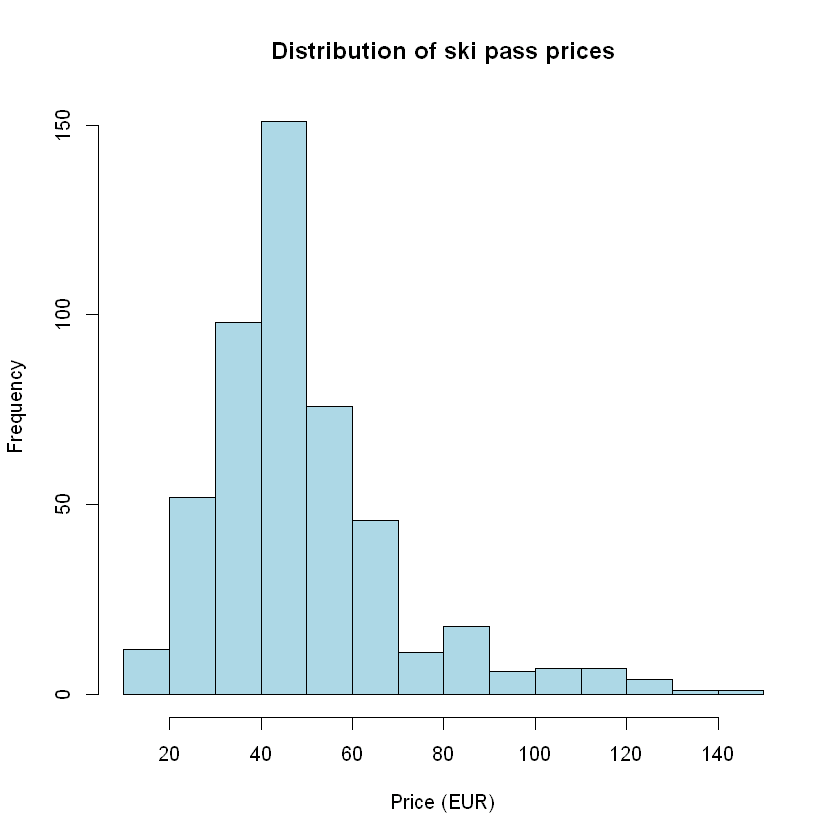

In [12]:
# Price distribution
summary(resorts$Price)
hist(resorts$Price,
     main = "Distribution of ski pass prices",
     xlab = "Price (EUR)",
     col = "lightblue")

The mean (51.4 EUR) is higher than the median (45 EUR), indicating a
**right-skewed distribution** — a few premium resorts pull the average up.

## Correlation Tests

**Hypotheses for all correlation tests:**

-   H0: the correlation coefficient = 0 (no linear relationship)
-   H1: the correlation coefficient ≠ 0 (a linear relationship exists)

In [13]:
# Price vs maximum altitude
cor.test(resorts$`Highest point`, resorts$Price, use = "pairwise.complete.obs")

# Price vs total number of slopes
cor.test(resorts$`Total slopes`, resorts$Price, use = "pairwise.complete.obs")

# Price vs total number of lifts
cor.test(resorts$`Total lifts`, resorts$Price, use = "pairwise.complete.obs")

# Price vs vertical drop
cor.test(resorts$Vertical_Drop, resorts$Price, use = "pairwise.complete.obs")


	Pearson's product-moment correlation

data:  resorts$`Highest point` and resorts$Price
t = 9.7934, df = 488, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.3284974 0.4767516
sample estimates:
      cor 
0.4052857 



	Pearson's product-moment correlation

data:  resorts$`Total slopes` and resorts$Price
t = 7.1011, df = 488, p-value = 4.398e-12
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.2235080 0.3841972
sample estimates:
      cor 
0.3060306 



	Pearson's product-moment correlation

data:  resorts$`Total lifts` and resorts$Price
t = 2.2946, df = 487, p-value = 0.02218
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.0148856 0.1903480
sample estimates:
      cor 
0.1034214 



	Pearson's product-moment correlation

data:  resorts$Vertical_Drop and resorts$Price
t = 3.7949, df = 488, p-value = 0.0001663
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.08195443 0.25407810
sample estimates:
     cor 
0.169307 


**Findings:**

-   `Highest point`: r ≈ 0.41, p \< 0.001 → **moderate positive correlation**
-   `Total slopes`: r ≈ 0.31, p \< 0.001 → **moderate positive correlation**
-   `Total lifts`: r ≈ 0.10, p ≈ 0.02 → weak but significant
-   `Vertical_Drop`: r ≈ 0.17, p \< 0.001 → weak but significant

The strongest single predictor is **maximum altitude**, not size per se.

## ANOVA: Price by Altitude Band

**Hypotheses:**

-   H0: mean price is equal across all altitude bands
-   H1: at least one altitude band has a significantly different mean price

In [14]:
anova_altitude <- aov(Price ~ Altitude_Band, data = resorts)
summary(anova_altitude)
TukeyHSD(anova_altitude)

               Df Sum Sq Mean Sq F value Pr(>F)    
Altitude_Band   3  43229   14410   41.21 <2e-16 ***
Residuals     486 169923     350                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
9 osservazioni eliminate a causa di valori mancanti

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Price ~ Altitude_Band, data = resorts)

$Altitude_Band
                       diff       lwr       upr     p adj
Medium-Low        0.5183486 -5.136399  6.173097 0.9953517
High-Low         13.8433951  7.714250 19.972540 0.0000001
Very_High-Low    40.6119266 28.885991 52.337862 0.0000000
High-Medium      13.3250465  8.137784 18.512309 0.0000000
Very_High-Medium 40.0935780 28.831303 51.355853 0.0000000
Very_High-High   26.7685315 15.260748 38.276315 0.0000000


## Preliminary Conclusion for Suspect 1

> Structural factors — particularly maximum altitude and number of slopes —
> show a clear positive relationship with price. However, the strength is
> moderate at best, suggesting that "bigger = more expensive" is only part
> of the story.

------------------------------------------------------------------------

# Suspect 2 — Geography and Wealth {#sec-suspect2}

**Assigned to: \[Name 2\]**

**Hypothesis:** prices vary systematically by region not just because of
geography, but because of the economic context of each country (purchasing
power, cost of living, tourism market structure).

## Price by Continent

In [15]:
resorts %>%
  group_by(Continent) %>%
  summarise(
    N = n(),
    Mean_Price = round(mean(Price, na.rm = TRUE), 2),
    Median_Price = median(Price, na.rm = TRUE),
    SD_Price = round(sd(Price, na.rm = TRUE), 2)
  )

Continent,N,Mean_Price,Median_Price,SD_Price
<chr>,<int>,<dbl>,<dbl>,<dbl>
Asia,24,39.10,41,11.10
Europe,360,41.90,43,10.83
North America,98,77.76,70,25.50
Oceania,10,70.33,74,14.92
South America,7,56.71,57,7.20


## ANOVA: Price by Continent

**Hypotheses:**

-   H0: mean price is equal across all continents
-   H1: at least one continent has a significantly different mean price

In [16]:
anova_continent <- aov(Price ~ Continent, data = resorts)
summary(anova_continent)
TukeyHSD(anova_continent)

             Df Sum Sq Mean Sq F value Pr(>F)    
Continent     4 104550   26137   116.7 <2e-16 ***
Residuals   485 108602     224                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
9 osservazioni eliminate a causa di valori mancanti

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Price ~ Continent, data = resorts)

$Continent
                                  diff         lwr       upr     p adj
Europe-Asia                   2.796359  -6.6184988 12.211216 0.9265291
North America-Asia           38.662887  28.6008883 48.724885 0.0000000
Oceania-Asia                 31.233333  14.7875366 47.679130 0.0000029
South America-Asia           17.614286  -0.3789818 35.607553 0.0583539
North America-Europe         35.866528  31.1751533 40.557903 0.0000000
Oceania-Europe               28.436975  14.6084022 42.265547 0.0000003
South America-Europe         14.817927  -0.8192997 30.455154 0.0729114
Oceania-North America        -7.429553 -21.7065869  6.847480 0.6118908
South America-North America -21.048601 -37.0837852 -5.013417 0.0032884
South America-Oceania       -13.619048 -34.2672329  7.029138 0.3712467


## Correlation with National Wealth

Once the external GDP and Cost of Living data are merged in Section 2.6:

In [17]:
# Correlation: price vs GDP per capita
# cor.test(resorts$GDP_per_capita, resorts$Price, use = "pairwise.complete.obs")

# Correlation: price vs Cost of Living Index
# cor.test(resorts$Cost_of_Living, resorts$Price, use = "pairwise.complete.obs")

## Chi-Square: Continent vs Price Category

**Hypotheses:**

-   H0: continent and price category are independent
-   H1: continent and price category are associated

In [18]:
# Create a categorical price variable using terciles
# resorts$Price_Category <- cut(resorts$Price,
#                               breaks = quantile(resorts$Price, probs = c(0, 1/3, 2/3, 1), na.rm = TRUE),
#                               labels = c("Low", "Medium", "High"),
#                               include.lowest = TRUE)

# Contingency table
# tab_geo <- table(resorts$Continent, resorts$Price_Category)
# tab_geo
# addmargins(tab_geo)
# round(prop.table(tab_geo, margin = 1), 3) * 100

# Chi-square test
# chisq.test(tab_geo)

# Strength of association
# cramerV(tab_geo)

## Preliminary Conclusion for Suspect 2

> *To be written based on results.* Expected: North American resorts charge
> substantially more, and this gap is partly — but probably not fully —
> explained by differences in national wealth and cost of living.

------------------------------------------------------------------------

# Suspect 3 — Services and Commercial Positioning {#sec-suspect3}

**Assigned to: \[Name 3\]**

**Hypothesis:** additional services (snowparks, night skiing, summer skiing,
family-friendly facilities) command a price premium because they target
specific customer segments willing to pay more.

## Service Variables Distribution

In [19]:
table(resorts$Snowparks)
table(resorts$Nightskiing)
table(resorts$`Summer skiing`)
table(resorts$`Child friendly`)


 No Yes 
121 378 


 No Yes 
295 204 


 No Yes 
470  29 


 No Yes 
  4 495 

## T-tests: Price by Each Service

**Hypotheses (for each service):**

-   H0: mean price is the same for resorts with vs without the service
-   H1: mean price differs between resorts with vs without the service

In [20]:
# Snowpark
t.test(resorts$Price[resorts$Snowparks == "Yes"],
       resorts$Price[resorts$Snowparks == "No"])

# Night skiing
t.test(resorts$Price[resorts$Nightskiing == "Yes"],
       resorts$Price[resorts$Nightskiing == "No"])

# Summer skiing
t.test(resorts$Price[resorts$`Summer skiing` == "Yes"],
       resorts$Price[resorts$`Summer skiing` == "No"])

# Child friendly
t.test(resorts$Price[resorts$`Child friendly` == "Yes"],
       resorts$Price[resorts$`Child friendly` == "No"])


	Welch Two Sample t-test

data:  resorts$Price[resorts$Snowparks == "Yes"] and resorts$Price[resorts$Snowparks == "No"]
t = 4.4291, df = 202.14, p-value = 1.549e-05
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
  5.16222 13.44648
sample estimates:
mean of x mean of y 
 51.80000  42.49565 



	Welch Two Sample t-test

data:  resorts$Price[resorts$Nightskiing == "Yes"] and resorts$Price[resorts$Nightskiing == "No"]
t = -0.63665, df = 479.23, p-value = 0.5247
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -4.801252  2.451349
sample estimates:
mean of x mean of y 
 48.92574  50.10069 



	Welch Two Sample t-test

data:  resorts$Price[resorts$`Summer skiing` == "Yes"] and resorts$Price[resorts$`Summer skiing` == "No"]
t = 4.1262, df = 33.001, p-value = 0.0002348
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
  6.581316 19.384052
sample estimates:
mean of x mean of y 
 61.85714  48.87446 



	Welch Two Sample t-test

data:  resorts$Price[resorts$`Child friendly` == "Yes"] and resorts$Price[resorts$`Child friendly` == "No"]
t = 0.3471, df = 3.0432, p-value = 0.7511
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -31.55762  39.35392
sample estimates:
mean of x mean of y 
 49.64815  45.75000 


## ANOVA: Price by Seasonality

Using the recoded `Season` variable. Note: `Year_Round` and `Multi_Season`
groups are small (4 each), so this analysis is exploratory.

**Hypotheses:**

-   H0: mean price is equal across all seasonality types
-   H1: at least one seasonality type has a significantly different mean price

In [21]:
anova_season <- aov(Price ~ Season, data = resorts)
summary(anova_season)
TukeyHSD(anova_season)

             Df Sum Sq Mean Sq F value Pr(>F)  
Season        3   3849    1283   2.916 0.0339 *
Residuals   460 202381     440                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
35 osservazioni eliminate a causa di valori mancanti

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Price ~ Season, data = resorts)

$Season
                                diff       lwr        upr     p adj
Summer_Only-Multi_Season  -2.8289474 -32.58131 26.9234188 0.9948172
Winter_Only-Multi_Season -14.7625858 -41.92779 12.4026181 0.4991952
Year_Round-Multi_Season   -3.5000000 -41.74277 34.7427744 0.9953705
Winter_Only-Summer_Only  -11.9336384 -24.60809  0.7408165 0.0733401
Year_Round-Summer_Only    -0.6710526 -30.42342 29.0813136 0.9999293
Year_Round-Winter_Only    11.2625858 -15.90262 38.4277897 0.7086030


## Chi-Square: Service Availability by Continent

**Hypotheses:**

-   H0: service availability is independent of continent
-   H1: service availability is associated with continent

In [22]:
# Example: summer skiing by continent
tab_summer <- table(resorts$Continent, resorts$`Summer skiing`)
tab_summer
addmargins(tab_summer)
round(prop.table(tab_summer, margin = 1), 3) * 100

chisq.test(tab_summer)
cramerV(tab_summer)

               
                 No Yes
  Asia           24   0
  Europe        349  11
  North America  97   1
  Oceania         0  10
  South America   0   7

,No,Yes,Sum
Asia,24,0,24
Europe,349,11,360
North America,97,1,98
Oceania,0,10,10
South America,0,7,7
Sum,470,29,499


               
                   No   Yes
  Asia          100.0   0.0
  Europe         96.9   3.1
  North America  99.0   1.0
  Oceania         0.0 100.0
  South America   0.0 100.0

Warning message in chisq.test(tab_summer):
"L'approssimazione al Chi-quadrato potrebbe essere inesatta"



	Pearson's Chi-squared test

data:  tab_summer
X-squared = 286.1, df = 4, p-value < 2.2e-16


Cramer V 
  0.7572

## Preliminary Conclusion for Suspect 3

> *To be written based on results.* Expected: services like snowparks and
> night skiing add a measurable premium, but summer skiing is geographically
> determined (Southern Hemisphere / glaciers) rather than a pure positioning
> choice.

------------------------------------------------------------------------

# Suspect 4 — The Actual Snow {#sec-suspect4}

**Assigned to: \[Name 4\]**

**Hypothesis:** resorts with more reliable natural snow cover can charge
higher prices because they offer a better and more predictable skiing
experience.

## Loading the Snow Dataset

In [23]:
# snow <- import("data/snow.csv")
# str(snow)
# nrow(snow)
# 
# # snow.csv contains monthly snow values for grid points (Lat/Lon) in 2022
# # Each row: Month, Latitude, Longitude, Snow (snow cover indicator)

## Aggregating Snow Data per Resort

The snow dataset has snow values for a geographic grid; we need to associate
each resort with nearby snow measurements. The simplest approach is to round
latitude and longitude to a common precision and aggregate.

In [24]:
# Round coordinates to 0.25 degrees (matches typical grid spacing)
# snow_agg <- snow %>%
#   mutate(Lat_round = round(Latitude * 4) / 4,
#          Lon_round = round(Longitude * 4) / 4) %>%
#   group_by(Lat_round, Lon_round) %>%
#   summarise(Mean_Snow = mean(Snow, na.rm = TRUE),
#             Max_Snow = max(Snow, na.rm = TRUE),
#             .groups = "drop")
# 
# resorts <- resorts %>%
#   mutate(Lat_round = round(Latitude * 4) / 4,
#          Lon_round = round(Longitude * 4) / 4) %>%
#   left_join(snow_agg, by = c("Lat_round", "Lon_round"))
# 
# # How many resorts got matched?
# sum(!is.na(resorts$Mean_Snow))

## Correlation: Snow vs Price

**Hypotheses:**

-   H0: there is no linear relationship between snow cover and price
-   H1: there is a linear relationship between snow cover and price

In [25]:
# cor.test(resorts$Mean_Snow, resorts$Price, use = "pairwise.complete.obs")

## Correlation: Snow vs Altitude

A natural validity check — we expect strong positive correlation:

In [26]:
# cor.test(resorts$Mean_Snow, resorts$`Highest point`, use = "pairwise.complete.obs")

## ANOVA: Snow by Continent

**Hypotheses:**

-   H0: mean snow cover is equal across all continents
-   H1: at least one continent has significantly different mean snow cover

In [27]:
# anova_snow_continent <- aov(Mean_Snow ~ Continent, data = resorts)
# summary(anova_snow_continent)
# TukeyHSD(anova_snow_continent)

## Preliminary Conclusion for Suspect 4

> *To be written based on results.* Expected: actual snow cover is more
> strongly tied to altitude and latitude than to price directly, suggesting
> that "snow reliability" is already partly priced in through altitude.

------------------------------------------------------------------------

# Synthesis: The Verdict {#sec-synthesis}

Sections 4–7 interrogated each suspect **in isolation**, one bivariate test
at a time. But real-world price formation is **entangled**: North American
resorts charge more — yet they are *also* larger, higher, and better
serviced, so a single test can never tell us which trait is doing the work.

The natural next step would be a multiple linear regression that weighs all
predictors simultaneously. That technique falls outside the methods covered
in our course, so instead we take a **summary-table approach**: we consolidate
every bivariate result from Sections 4–7 into one table, rank the factors by
the **strength of their effect**, and read the research answer off that
ranking by comparing the *relative importance* of the suspects.

This keeps us strictly within the bivariate toolkit (correlation, ANOVA,
t-tests, chi-square) while still delivering a single, comparable verdict.

## Consolidated Summary Table

In [ ]:
# Consolidate every bivariate result from Sections 4-7 into one table.
# All numbers are taken directly from the test outputs above.
# NA / "TBD" mark tests that depend on external data not yet merged.

summary_table <- data.frame(
  Factor = c(
    "Maximum altitude (Highest point)",
    "Total slopes",
    "Total lifts",
    "Vertical drop",
    "Altitude band",
    "Continent",
    "National wealth (GDP per capita)",
    "Continent vs price category",
    "Snowpark presence",
    "Night skiing",
    "Summer skiing",
    "Child friendly",
    "Seasonality (Season)",
    "Summer skiing vs continent",
    "Snow cover vs price",
    "Snow cover vs altitude",
    "Snow cover by continent"
  ),
  Test_Type = c(
    "Correlation", "Correlation", "Correlation", "Correlation",
    "ANOVA",
    "ANOVA",
    "Correlation",
    "Chi-square",
    "T-test", "T-test", "T-test", "T-test",
    "ANOVA",
    "Chi-square",
    "Correlation", "Correlation", "ANOVA"
  ),
  Statistic = c(
    0.41, 0.31, 0.10, 0.17,      # r values
    41.21,                       # F (altitude band)
    116.70,                      # F (continent)
    NA,                          # GDP correlation (data pending)
    NA,                          # continent vs price category (pending)
    4.43, -0.64, 4.13, 0.35,     # t values (services)
    2.92,                        # F (season)
    286.10,                      # Chi-square (summer skiing vs continent)
    NA, NA, NA                   # snow tests (data pending)
  ),
  P_value = c(
    "<0.001", "<0.001", "0.022", "<0.001",
    "<0.001",
    "<0.001",
    "TBD",
    "TBD",
    "<0.001", "0.525", "<0.001", "0.751",
    "0.034",
    "<0.001",
    "TBD", "TBD", "TBD"
  ),
  Effect_Strength = c(
    "Moderate", "Moderate", "Weak", "Weak",
    "Moderate",
    "Strong",
    NA,
    NA,
    "Moderate", "Negligible", "Moderate", "Negligible",
    "Weak",
    "Strong",
    NA, NA, NA
  ),
  Interpretation = c(
    "Higher resorts charge more; strongest single numeric predictor (r = 0.41).",
    "Larger ski areas cost more, but the link is only moderate (r = 0.31).",
    "Number of lifts is barely related to price (r = 0.10).",
    "Vertical drop has a weak positive link with price (r = 0.17).",
    "Price climbs across altitude bands: Very High is ~41 EUR above Low.",
    "Largest price gaps of all: North America ~+36 EUR vs Europe.",
    "Awaiting World Bank GDP per capita merge (Section 2.6).",
    "Awaiting categorical price variable and contingency table.",
    "Snowparks add a real premium of ~9 EUR (51.8 vs 42.5).",
    "No price difference between resorts with vs without night skiing.",
    "Apparent +13 EUR premium, but confounded with hemisphere / glaciers.",
    "Almost universal (495/499): no usable contrast, not significant.",
    "Seasonality barely moves price; effect is small and borderline.",
    "Strong service-geography link (V = 0.76): summer skiing is locational.",
    "Awaiting aggregated snow cover per resort.",
    "Validity check awaiting snow data (expected strong positive).",
    "Awaiting snow data; expected differences by continent."
  ),
  stringsAsFactors = FALSE
)

summary_table

In [ ]:
# Rank by effect strength (strongest first); rows with pending data fall to
# the bottom because their Effect_Strength is NA.
strength_levels <- c("Negligible", "Weak", "Moderate", "Strong", "Very strong")

summary_ranked <- summary_table %>%
  mutate(Strength_rank = factor(Effect_Strength, levels = strength_levels, ordered = TRUE)) %>%
  arrange(desc(Strength_rank), desc(abs(Statistic))) %>%
  select(-Strength_rank)

# Note: the secondary sort by |Statistic| only orders rows *within* the same
# strength tier; r, F, t and Chi-square values are not directly comparable.
print(summary_ranked, row.names = FALSE)

## Interpretation: Ranking the Suspects

**The top three drivers.** Ordered by effect strength, the podium is clear.
**Continent** is the single most powerful factor (ANOVA F = 116.7, p < 0.001):
North American resorts charge on average about **36 EUR more** than European
ones, the largest gap anywhere in the study. **Maximum altitude** comes
second — it is both the strongest numeric correlation with price (r = 0.41,
p < 0.001) and a clear ANOVA effect across altitude bands (F = 41.2), with
"Very High" resorts costing ~41 EUR more than "Low" ones. **Resort size**,
captured by total slopes (r = 0.31, p < 0.001), rounds out the top three:
bigger ski areas cost more, though only moderately.

**The weak suspects.** Several factors mattered far less than intuition
suggested. The **number of lifts** (r = 0.10) and **vertical drop** (r = 0.17)
are statistically significant but practically negligible — counting lifts
tells you almost nothing about price. **Seasonality** barely moved the needle
(ANOVA F = 2.9, p = 0.034), and two services we expected to command a premium
did not: **night skiing** (p = 0.52) and **child-friendly facilities**
(p = 0.75) showed *no* significant price difference at all. Child-friendliness
is essentially universal in the dataset (495 of 499 resorts), so it carries no
discriminating signal.

**The surprises.** Two findings cut against intuition. First, services are not
a uniform premium lever: snowparks do add a real ~9 EUR premium (p < 0.001),
but night skiing and child-friendliness add nothing — "more amenities" is not
automatically "more expensive". Second, **summer skiing** looks like a strong
premium (+13 EUR, p < 0.001) until you notice it is almost perfectly
**geographic**: the chi-square test links summer skiing to continent with a
very strong Cramer's V of 0.76. Summer skiing exists essentially only in the
Southern Hemisphere and on a handful of glaciers, so its "premium" is really a
continent effect wearing a different hat.

**The limitation we cannot escape.** Every row in the table is a *bivariate*
result, and bivariate tests cannot disentangle confounded causes. North
America shows the highest prices — but is it because of the continent
*itself*, or because North American resorts are *also* larger, higher, and
more serviced? The summer-skiing example above shows the same trap concretely.
Ranking effects by strength tells us *which* suspects are associated with price
and *how strongly*, but it cannot assign sole responsibility to any one of
them. Separating these intertwined effects would require a multivariate model
(e.g. multiple regression), which lies beyond this course — see the
**Limitations** in Section 9.

# Conclusions {#sec-conclusions}

## Answer to the Research Question

*To be written.* A one-sentence synthesis along the lines of:

> "Ski pass prices are driven primarily by \[\_\_\_\], while \[\_\_\_\] matters less than initial intuition would suggest."

## The Surprise

*To be written.* Every good analysis has at least one counterintuitive
finding. Identify and explain the most interesting one.

## Limitations

-   The dataset contains 9 prices masked as zero (handled as NA)
-   The `Season` variable required heavy recoding from 31 raw values
-   Oceania (10) and South America (7) are heavily underrepresented
-   Prices are a snapshot in time (2023) — no temporal dimension
-   Correlation does not imply causation: the regression identifies
    *associations*, not causal mechanisms
-   External data sources (GDP, Cost of Living) are at the country level,
    not at the resort level — this introduces ecological inference issues

## Practical Implications

*To be written.* Who could use these findings?

-   Tourists choosing a destination on a budget
-   New resorts setting their pricing strategy
-   Tourism boards positioning their offer
-   Investors evaluating ski resort acquisitions

## Open Questions

*To be written.* What new questions does this analysis raise that we could
not answer? Climate change impacts, multi-year price evolution, customer
behavior data, etc.

------------------------------------------------------------------------

# Data Sources and References

-   **Ski Resorts dataset**: Pedersen, U. T. (2023). *Ski Resorts*.
    Kaggle. <https://www.kaggle.com/datasets/ulrikthygepedersen/ski-resorts>
-   **Snow Cover dataset**: included in the Kaggle package above (`snow.csv`)
-   **GDP per capita**: World Bank Open Data, 2022.
    <https://data.worldbank.org/indicator/NY.GDP.PCAP.CD>
-   **Cost of Living Index**: Numbeo, 2022. <https://www.numbeo.com/cost-of-living/>

------------------------------------------------------------------------

# Appendix: Session Info